In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from pathlib import Path
import sys
import html as html_lib
from IPython.display import HTML, display as ipy_display
import matplotlib.pyplot as plt

root = Path.cwd().resolve()
root = root.parent
sys.path.insert(0, str(root))

import torch
from collections import defaultdict
from transformers import AutoTokenizer, AutoModelForCausalLM
from sae_trainer.model_utils import SparseAutoencoder
from sae_trainer.feature_tracer_utils import FeatureTracer, TraceConfig
from sae_trainer.feature_tracer_eval_utils import top_n_feats_by_hits_count, top_n_feats_by_act_mass, prompt_x_feature_heatmap, feature_token_position_profile, top_m_feature_coactivation, render_feature_card, plot_feature_umap, plot_inter_feature_similarity

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
layer_idx = 6

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
llm = AutoModelForCausalLM.from_pretrained(model_name).to(device).eval()

# Load SAE checkpoint — pick whichever layer you want to analyse (3, 6, 9, or 11)
ckpt = torch.load(f"sae_gpt2_layer{layer_idx}.pt", map_location=device)
sae = SparseAutoencoder(d_in=ckpt["d_in"], d_latent=ckpt["d_latent"], normalize_decoder=True).to(device)
sae.load_state_dict(ckpt["model_state"])
sae.eval()

SparseAutoencoder(
  (encoder): Linear(in_features=768, out_features=6144, bias=True)
  (decoder): Linear(in_features=6144, out_features=768, bias=False)
)

In [8]:
# 4) Tracer config — layer_idx MUST match the checkpoint loaded above
cfg = TraceConfig(
    layer_idx=layer_idx,
    topk_per_token=8,
    min_activation=0.01,
    max_new_tokens=10,
    do_sample=True,
    temperature=0.7,
)
tracer = FeatureTracer(llm, tokenizer, sae, device, cfg)

In [9]:
from datasets import load_dataset

ds = load_dataset("Skylion007/openwebtext", split="train", streaming=True, trust_remote_code=True)

summaries = tracer.trace_prompts_from_iterable_dataset(ds, max_prompts_to_trace=100)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Skylion007/openwebtext' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


In [10]:
# Score all features (calls compute_feature_embeddings internally)
scores = tracer.feature_specificity_scores()
display(scores.head(20))

# Or run embedding + scoring separately if you want to reuse the embeddings
#embeddings = tracer.compute_feature_embeddings(
#    feature_ids=tracer.top_features(50)["feature_id"].tolist(),
#    contexts_per_feature=30,
#)
#scores = tracer.feature_specificity_scores(feature_embeddings=embeddings)
#display(scores.head(20))


,feature_id,hits,mean_activation,specificity,specificity_vs_baseline
0,2612,3,5.521691,0.360817,0.281017
1,3912,2,5.359390,0.352028,0.272228
2,5867,2,5.847131,0.337032,0.257232
3,4859,2,5.052033,0.317556,0.237755
4,484,3,6.445580,0.294294,0.214493
5,1112,6,5.537548,0.288259,0.208459
6,2674,2,5.387876,0.283344,0.203544
7,3810,2,5.639694,0.281690,0.201890
8,5027,2,5.341834,0.277851,0.198051
9,744,2,4.605837,0.270496,0.190695


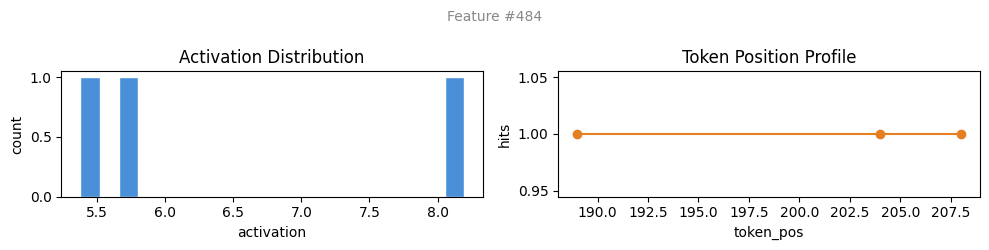

In [17]:
render_feature_card(484, tracer)

In [8]:
display(scores.tail(20))

,feature_id,hits,mean_activation,specificity,specificity_vs_baseline
538,126,1,3.970858,NaN,NaN
539,3862,1,3.696140,NaN,NaN
540,2454,1,4.365855,NaN,NaN
541,5469,1,3.860838,NaN,NaN
542,1387,1,3.683710,NaN,NaN
543,5724,1,3.083655,NaN,NaN
544,5108,1,4.025950,NaN,NaN
545,1747,1,3.508741,NaN,NaN
546,4885,1,3.457937,NaN,NaN
547,286,2,3.966413,NaN,NaN


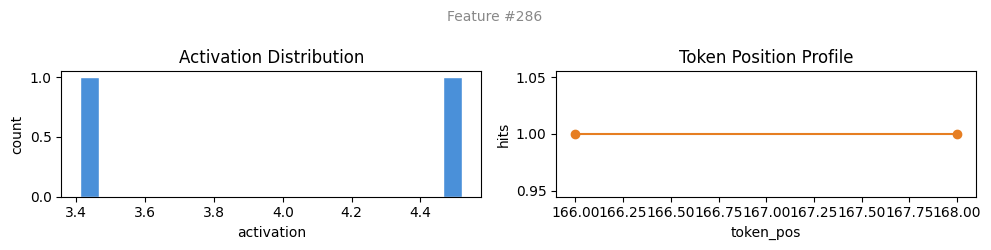

In [9]:
render_feature_card(286, tracer)

In [ ]:
# Note: can't test this yet, can't install umap
# plot_feature_umap(tracer, top_n=20)

ImportError: pip install umap-learn

In [ ]:
# Note: can't test this yet, can't install umap
#plot_inter_feature_similarity(tracer)